In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

<h1>Binomial Tree European Option Pricing</h1>

The binomial tree model is a discrete-time method used to price options. It approximates the continuous evolution of stock prices by assuming that, over a small time interval, the price can move to only two possible values: `up` or `down`.

As the number of time steps increases, the model converges toward the continuous-time solution (such as Black–Scholes).

This model is particularly useful because it can be extended to price American options.

<h3>Mathematical Framework</h3>

In each time step, the stock can either move up or down. I'm adjusting **up** and **down** for *underlying* volatility.<br>

**u** is up factor.
$$
    u = e^{\sigma\sqrt{dt}}
$$

**d** is down factor.
$$
    d = e^{-\sigma\sqrt{dt}}
$$

**dt** is the time-step.
$$
    dt = T/N
$$

Under risk-neutral valuation, expected payoff is equal to risk-free-rate. The probability in this valuation is called **risk neutral probability**.
$$
    p = \frac{e^{rdt} - d}{u - d}
$$

At maturity, the payoff for `Call Option`:
$$
    max(S_t - K, 0)
$$

At maturity, the payoff for `Put Option`:
$$
    max(K - S_t, 0)
$$

I'll be using backward induction to compute the current option price.
$$
    C_0  = e^{-rt} \ [\ p \ C^u_1 + (1-p) \ C^d_1 \ ]
$$

In [2]:
def binomial_eu_option(S_in, K, T, r, sigma, N, opt_type):
    #parameters calculations
    dt = T/N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    S = np.zeros([N + 1, N + 1])
    C = np.zeros([N + 1, N + 1])
    #iteration throught each node
    for i in range(0, N+1): 
        S[N, i] = S_in * u**(i) * d**(N-i)
        if opt_type == "C":
            C[N, i] = max(S[N, i] - K, 0)
        else:
            C[N, i] = max(K - S[N, i], 0)
        for j in range(N-1, -1, -1):
            for i in range(0, j + 1):
                S[j, i] = S_in * u**(i) * d**(j - i)
                C[j, i] = np.exp(-r * dt) * p*(C[j + 1, i + 1]) + (1-p)*(C[j + 1, i])
    return S, C

In [3]:
S, C = binomial_eu_option(100, 90, 10, 0, 0.3, 100, opt_type='C')
euro_call = C[0,0]
print('Price of a Euro Call Option:', euro_call)

Price of a Euro Call Option: 39.92003274332957


In [4]:
S, C = binomial_eu_option(100, 90, 10, 0, 0.3, 100, opt_type='P')
euro_put = C[0,0]
print('Price of a Euro Put Option:', euro_put)

Price of a Euro Put Option: 29.920032743329557


<h1>Put Call Parity</h1>

Put–call parity is a fundamental no-arbitrage relationship between European call and put options with the same strike and maturity.<br>
It ensures that there is no risk-free arbitrage opportunity between options and the underlying asset.

Mathematical Relationship:
$$
    C + Ke^{-rt} = S_0 + P
$$

By rearranging, we can get equation for `put`.
$$
    P = C + Ke^{-rt} - S_0
$$

Now I'll use the parity formula to price the put option with same parameters to check whether the price of *put* is same as the binomial function.  

In [5]:
def put_call_parity(call, K, T, r, S_in):
    put = call + (K * np.exp(-r*T)) - S_in
    return put

In [6]:
put  = put_call_parity(euro_call, 90, 10, 0, 100)
print('Price of a Euro Put Option:', put)

Price of a Euro Put Option: 29.920032743329557


Price from **binomial function** and **put-call-parity** for `Put` is same.

<h1>Trinomial Tree European Option Pricing</h1>

The trinomial tree is an extension of the binomial model. Instead of two possible movements, the stock can move `up`, `stay the same (middle state)`, and `down`.

This additional state improves numerical stability and often leads to faster convergence compared to the binomial model.

<h3>Mathematical Framework</h3>

**u** is up factor.
$$
    u = e^{\sigma\sqrt{2dt}}
$$

**d** is down factor.
$$
    d = \frac{1}{u}
$$

**m** is middle state, which is 1.

There are `three` probabilities:<br>
**pu** is up probability.
$$
    pu = \left(\frac{e^\frac{rdt}{2} - e^{-\sigma\sqrt\frac{dt}{2}}}{e^{\sigma\sqrt\frac{dt}{2}} - e^{-\sigma\sqrt\frac{dt}{2}}} \right)^2
$$

**pd** is down probability.
$$
    pd = \left(\frac{e^{\sigma\sqrt\frac{dt}{2}} - e^{\frac{rdt}{2}}}{e^{\sigma\sqrt\frac{dt}{2}} - e^{-\sigma\sqrt\frac{dt}{2}}} \right)^2
$$

**pm** is middle probability.
$$
    pm = 1 - pu - pd
$$

At each node, the option price is computed as:
$$
    C = e^{-rdt}(p_uC_u + p_mC_m + p_dC_d)
$$

In [7]:
def trinomial_eu_option(S_in, K, T, r, sigma, N, opt_type):
    #Time step and tree parameters
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1 / u

    #Risk-neutral probabilities
    pu = (
        (np.exp(r * dt / 2) - np.exp(-sigma * np.sqrt(dt / 2)))
        / (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2)))
    ) ** 2

    pd = (
        (-np.exp(r * dt / 2) + np.exp(sigma * np.sqrt(dt / 2)))
        / (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2)))
    ) ** 2

    pm = 1 - pu - pd

    #Inner function to generate stock prices at a given time level
    def asset_price(nb):
        if nb == 0:
            return np.array([S_in])
        vec_u = u * np.ones(nb)
        np.cumprod(vec_u, out=vec_u)          # [u, u², u³, ...]
        vec_d = d * np.ones(nb)
        np.cumprod(vec_d, out=vec_d)          # [d, d², d³, ...]
        # Combine: d^nb ... d², d¹, 1, u¹, u², ... u^nb
        multipliers = np.concatenate((vec_d[::-1], [1.0], vec_u))
        return multipliers * S_in

    #Stock prices at expiration (time T)
    S_final = asset_price(N)
    #Payoff at expiration
    if opt_type == "C":
        payoff = np.maximum(S_final - K, 0)
    else:
        payoff  = np.maximum(K - S_final, 0)
    nxt_vec_prices = payoff          # option values at the next (future) time step

    #Backward induction through the tree
    for i in range(1, N + 1):
        #Stock prices at current time level (i steps before expiration)
        S_current = asset_price(N - i)
        expectation = np.zeros(len(S_current))

        for j in range(len(S_current)):
            #From node j, the three future nodes are at indices j, j+1, j+2
            exp_val = (pd * nxt_vec_prices[j] +
                       pm * nxt_vec_prices[j + 1] +
                       pu * nxt_vec_prices[j + 2])
            expectation[j] = exp_val

        #Discount back one time step
        nxt_vec_prices = np.exp(-r * dt) * expectation

    #The option price is the value at the single root node
    opt_price = nxt_vec_prices[0]
    return opt_price

In [8]:
trinomial_call = trinomial_eu_option(100, 90, 10, 0, 0.3, 100, opt_type='C')
print("Price of the Euro Call Option is:", trinomial_call)

Price of the Euro Call Option is: 39.85927517930929


In [9]:
trinomial_put = trinomial_eu_option(100, 90, 10, 0, 0.3, 100, opt_type='P')
print("Price of the Euro Put Option is:", trinomial_put)

Price of the Euro Put Option is: 29.859275179308938


<h2>Convergence</h2>

In [10]:
price_array = []
N = [1, 5, 10, 50, 100, 200, 300, 500, 600, 700, 800, 900, 1000, 1500, 2000]
for i in N:
    call = trinomial_eu_option(100, 90, 10, 0, 0.3, i, opt_type='C')
    price_array.append(call)
    print("With N = {:3d}, the price is {:.2f}".format(i, call))

With N =   1, the price is 37.96
With N =   5, the price is 39.90
With N =  10, the price is 40.01
With N =  50, the price is 39.92
With N = 100, the price is 39.86
With N = 200, the price is 39.84
With N = 300, the price is 39.86
With N = 500, the price is 39.85
With N = 600, the price is 39.84
With N = 700, the price is 39.85
With N = 800, the price is 39.85
With N = 900, the price is 39.85
With N = 1000, the price is 39.85
With N = 1500, the price is 39.85
With N = 2000, the price is 39.85


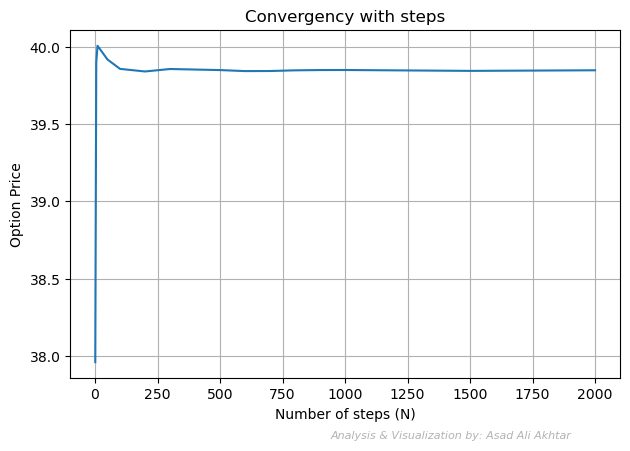

In [11]:
N = [1, 5, 10, 50, 100, 200, 300, 500, 600, 700, 800, 900, 1000, 1500, 2000]
plt.plot(N, np.array(price_array))
plt.title("Convergency with steps")
plt.xlabel("Number of steps (N)")
plt.ylabel("Option Price")
plt.grid(True)

plt.savefig('Convergence_plot.jpg')

plt.gcf().text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
               fontsize=8, 
               color='gray', 
               ha='right', 
               va='bottom', 
               alpha=0.6, 
               fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

As the number of steps increases, the price `converges` to its *true value*.

<h1>Binomial Tree American Option Pricing</h1>

American options differ from European options because they can be exercised at any time before expiration.<br> This means the holder may choose early exercise if it is optimal.

Tree methods are well suited for American options because they naturally *allow comparison* at each node between:
<ul>
    <li>Continuing the option</li>
    <li>Exercising immediately</li>
</ul>

<h3>Mathematical Framework</h3>

At each node:
$$
    Option \ Value = max(Continuation \ Value, Intrinsic \ Value)
$$

Continuation value:
$$
    e^{-rdt}[pC_u + (1-p)C_d]
$$

Intrinsic value for Call:
$$
    S - K
$$
Intrinsic value for Put:
$$
    K - S
$$

In [12]:
def binomial_american_options(S_in, K, T, r, sigma, N, opt_type):
    #parameters calculations
    dt = T/N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    S = np.zeros([N + 1, N + 1])
    C = np.zeros([N + 1, N + 1])
    #calculating terminal payoffs
    for i in range(0, N + 1):
        S[N, i] = S_in * u**(i) * d**(N - i)
        if opt_type == "C":
            C[N, i] = max(S[N, i] - K, 0)
        else:
            C[N, i] = max(K - S[N, i], 0)
    #backward induction
    for j in range(N - 1, -1, -1):
        for i in range(0, j + 1):
            S[j, i] = S_in * u**(i) * d**(j - i)
            C[j, i] = (np.exp(-r*dt)) * (p*(C[j + 1, i + 1]) + (1-p)*(C[j + 1, i]))
            if opt_type == "C":
                C[j, i] = max(C[j, i], S[j, i] - K)
            else:
                C[j, i] = max(C[j, i], K - S[j, i])
    return C[0,0]

In [13]:
american_call = binomial_american_options(100, 90, 10, 0, 0.3, 10, "C")
print('Price of the American Call Option is:', american_call)

Price of the American Call Option is: 39.899240766330934


In [14]:
american_put = binomial_american_options(100, 90, 10, 0, 0.3, 10, "P")
print('Price of the American Put Option is:', american_put)

Price of the American Put Option is: 29.89924076633092


Since I used `r` = 0, early exercise did not provide additional value, so *American* and *European* prices were <u>similar</u>.

<h1>Asian Option using Monte Carlo in Binomial Setting</h1>

Asian options are path-dependent options whose payoff depends on the average stock price over time rather than only the final price.<br>
Because the payoff depends on the entire price path, tree methods become computationally expensive as the number of steps increases.

`Monte Carlo` simulation is well suited for pricing such options because it simulates many possible price paths and estimates the expected payoff.

The accuracy of the Monte Carlo estimator depends directly on the number of simulated paths (M). As the number of simulations increases:<br>
<ul>
    <li>The estimate becomes more stable.</li>
    <li>The variance of the estimator decreases.</li>
    <li>The standard error reduces at a rate proportional to $\frac{1}{\sqrt{M}}$.</li>
</ul>

However, increasing the number of simulations also increases computational time, so there is a trade-off between accuracy and efficiency.

<h3>Mathematical Framework</h3>

1. Simulate stock price paths under risk-neutral measure.
2. Compute arithmetic average price along each path.
3. Calculate payoff:<br>
   Call
   $$
       max(\bar{S} - K, 0)
   $$
   Put
   $$
       max(K - \bar{S}, 0)
   $$
4. Discount the average payoff:
   $$
       Price = e^{-rT}\mathbb{E}[Payoff]
   $$
The expectation is approximated by averaging over `M` simulated paths

In [15]:
def asian_option(S_in, K, T, r, sigma, N, M, opt_type):
    dt = T/N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    S = np.zeros([M, N + 1])
    C = np.zeros([M])
    S[:,0] = S_in

    for j in range(0, M):
        random = np.random.binomial(1, p, N + 1)
        Total = S_in
        for i in range(1, N + 1):
            if random[i] == 1:
                S[j, i] = S[j, i - 1] * u
                Total  = Total + S[j, i]
            else:
                S[j, i] = S[j, i - 1] * d
                Total = Total + S[j, i]

        avg_price = Total / (N + 1)
        if opt_type == 'C':
            C[j] = np.exp(-r*T) * max(avg_price - K, 0)
        else:
            C[j] = np.exp(-r*T) * max(K - avg_price, 0)
    return C

In [16]:
asian = asian_option(100, 90, 10, 0, 0.3, 100, 10000, opt_type='C')
print("Price of the Asian Call Option is:", np.mean(asian))

Price of the Asian Call Option is: 25.72518585406127


In [17]:
asian = asian_option(100, 90, 10, 0, 0.3, 100, 10000, opt_type='P')
print("Price of the Asian Call Option is:", np.mean(asian))

Price of the Asian Call Option is: 15.307900346826116


This is `arithmetic` Asian option. No variance reduction technique was applied.

<h1>Black-Scholes European Option Pricing</h1>

The `Black–Scholes model` is a continuous-time model used to price European options. Unlike tree models, it assumes that the stock price follows a continuous stochastic process called Geometric Brownian Motion.

The Black–Scholes formula gives the theoretical fair value of the option under risk-neutral valuation.

The key assumptions are:
<ul>
    <li>The stock price follows a lognormal distribution.</li>
    <li>Mean and Volatility is constant.</li>
    <li>The risk-free rate is constant.</li>
    <li>No arbitrage opportunities exist.</li>
    <li>Markets are frictionless (no transaction costs).</li>
</ul>

Under these assumptions, a closed-form solution for European call and put options can be derived by solving a partial differential equation.

<h3>Mathematical Framework</h3>

**Black-Scholes-Merton** Stochastic Differential Equation:
$$
    \frac{\partial f}{\partial t} + rS\frac{\partial f}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 f}{\partial S^2} = rf
$$

<b> $\tau$ </b> is Time to maturity.
$$
    \tau = T - t
$$
where `T` is maturity date and `t` is current time.

Black-Scholes-Merton SDE closed-form solutions for call and put option prices.<br>
`Call option`:
$$
    C = S \mathcal{N}(d_1) - Ke^{-r\tau}\mathcal{N}(d_2)
$$

`Put option`:
$$
    P = Ke^{-r\tau}\mathcal{N}(-d_2) - S \mathcal{N}(-d_1)
$$
where $\mathcal{N()}$ is the comulative density function (CDF) of a standard normal.

Define:
$$
    d_1 = \frac{Ln(S/K) + (r + \sigma^2/2)\tau}{\sigma\sqrt{\tau}}
$$
$$
    d_2 = \frac{Ln(S/K) + (r - \sigma^2/2)\tau}{\sigma\sqrt{\tau}} = d_1 - \sigma\sqrt{\tau}
$$

In [18]:
def black_scholes(S_in, K, T, t, r, sigma, opt_type):
    time_to_maturity = T - t  #t is current time

    if time_to_maturity < 0.0:
        return 0.0
    elif time_to_maturity == 0.0:
        if opt_type == "C":
            return np.maximum(S_in - K, 0.0)
        else:
            return np.maximum(K - S_in, 0.0)
    
    d1 = (np.log(S_in / K) + (r + sigma**2 / 2) * time_to_maturity) / (sigma * np.sqrt(time_to_maturity)) 
    d2 = d1 - sigma * np.sqrt(time_to_maturity)

    if opt_type == "C":
        option = (S_in * norm.cdf(d1)) - (K * np.exp(-r * time_to_maturity) * norm.cdf(d2))
    else:
        option = (K * np.exp(-r * time_to_maturity) * norm.cdf(-d2)) - (S_in * norm.cdf(-d1))
    
    return option

In [19]:
black_schole_call = black_scholes(100.0, 90, 10, 0, 0, 0.3, opt_type="C")
print("Price of Euro Call option from Black_Scholes is:", black_schole_call)

Price of Euro Call option from Black_Scholes is: 39.848363476643065


In [20]:
black_schole_put = black_scholes(100.0, 90, 10, 0, 0, 0.3, opt_type="p")
print("Price of Euro Put option from Black_Scholes is:", black_schole_put)

Price of Euro Put option from Black_Scholes is: 29.848363476643065


The price from `Black-Scholes`, `Binomial-Tree`, and `Trinomial-Tree` are same.

<h3>Greeks in Black-Scholes</h3>

The Greeks measure the sensitivity of the option price to changes in underlying parameters. They are essential in risk management and hedging.

While pricing gives the theoretical value of an option, Greeks explain how that value changes when market conditions change.

**Delta**($\Delta$): It measures sensitivity to changes in stock price.

`Call option` $\Delta$:
$$
    \Delta = \frac{\partial C}{\partial S} = \mathcal{N}(d_1)
$$
`Put option` $\Delta$:
$$
    \Delta = \frac{\partial P}{\partial S} = \mathcal{N}(d_1) - 1
$$

**Gamma** ($\Gamma$): It measures sensitivity of Delta(change in underlying) to stock price changes.
$$
    \Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\mathcal{N}'(d_1)}{S\sigma\tau}
$$

**Vega** ($\nu$): It measures sensitivity to volatility.
$$
    \nu = \frac{\partial V}{\partial \sigma} = S\mathcal{N}'(d_1)\sqrt{\tau}
$$

**Theta** ($\Theta$): It measures sensitivity to time decay.

`Call option` $\Theta$:
$$
    \Theta = \frac{\partial C}{\partial t} = -\frac{S\mathcal{N}'(d_1)\sigma}{2\sqrt{\tau}} - rKe^{-r\tau}\mathcal{N}(d_2)
$$
`Put option` $\Theta$:
$$
     \Theta = \frac{\partial P}{\partial t} = -\frac{S\mathcal{N}'(d_1)\sigma}{2\sqrt{\tau}} + rKe^{-r\tau}\mathcal{N}(-d_2)
$$

**Rho** ($\rho$): It measures sensitivity to risk-free-rates.

`Call option` $\rho$:
$$
    \rho = \frac{\partial C}{\partial r} = K(\tau)e^{-r\tau}\mathcal{N}(d_2)
$$
`Put option` $\rho$:
$$
    \rho = \frac{\partial P}{\partial r} = -K(\tau)e^{-r\tau}\mathcal{N}(-d_2)
$$

In [21]:
def black_scholes_greek(S, K, T, t, r, sigma, opt_type):
    time_to_maturity = T - t

    if time_to_maturity <= 0:
        # Option expired or at expiry: Greeks are tricky, often return 0
        return 0.0, 0.0, 0.0, 0.0, 0.0

    
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * time_to_maturity) / (sigma * np.sqrt(time_to_maturity))
    d2 = d1 - sigma * np.sqrt(time_to_maturity)
    
    if opt_type == "C":
        Delta = norm.cdf(d1)
        Gamma = norm.pdf(d1) / (S * sigma * np.sqrt(time_to_maturity))
        Vega = S * norm.pdf(d1) * np.sqrt(time_to_maturity)
        Theta = -((S * norm.pdf(d1) * sigma) / (2 * np.sqrt(time_to_maturity))) - (r * K * np.exp(-r * time_to_maturity) * norm.cdf(d2))
        Rho = K * time_to_maturity * np.exp(-r * time_to_maturity) * norm.cdf(d2)

    else:
        Delta = norm.cdf(d1) - 1
        Gamma = norm.pdf(d1) / (S * sigma * np.sqrt(time_to_maturity))
        Vega = S * norm.pdf(d1) * np.sqrt(time_to_maturity)
        Theta = -((S * norm.pdf(d1) * sigma) / (2 * np.sqrt(time_to_maturity))) + (r * K * np.exp(-r * time_to_maturity) * norm.cdf(-d2))
        Rho = -(K * time_to_maturity * np.exp(-r * time_to_maturity) * norm.cdf(-d2))
        
    return Delta, Gamma, Vega, Theta, Rho

In [22]:
Delta, Gamma, Vega, Theta, Rho = black_scholes_greek(100.0, 90, 10, 0, 0, 0.3, opt_type="C")
print("Delta_call = {}".format(Delta))
print("Gamma = {}".format(Gamma))
print("Vega = {}".format(Vega))
print("Theta_call = {}".format(Theta))
print("Rho_call = {}".format(Rho))

Delta_call = 0.7208610708071791
Gamma = 0.0035430198463102017
Vega = 106.29059538930606
Theta_call = -1.5943589308395905
Rho_call = 322.3774360407485


In [23]:
Delta, Gamma, Vega, Theta, Rho = black_scholes_greek(100.0, 90, 10, 0, 0, 0.3, opt_type="P")
print("Delta_Put = {}".format(Delta))
print("Gamma = {}".format(Gamma))
print("Vega = {}".format(Vega))
print("Theta_Put = {}".format(Theta))
print("Rho_Put = {}".format(Rho))

Delta_Put = -0.2791389291928209
Gamma = 0.0035430198463102017
Vega = 106.29059538930606
Theta_Put = -1.5943589308395905
Rho_Put = -577.6225639592516


<h1>Conclusion</h1>

I implemented multiple numerical and analytical methods for pricing derivative securities. I began with discrete-time models including the binomial and trinomial trees, extended them to American options with early exercise features, and then priced path-dependent Asian options using Monte Carlo simulation. I also implemented the continuous-time Black–Scholes model and computed the option Greeks for risk sensitivity analysis.

The convergence analysis confirmed that discrete-time models approach the continuous-time Black–Scholes price as the number of steps increases. The consistency between binomial, trinomial, and Black–Scholes results validates the numerical accuracy of the implementations.

<h1>Future Imporvements</h1>

The project can be extended in several directions:
<ul>
    <li>Implement implied volatility calculation and volatility smile analysis.</li>
    <li>Introduce variance reduction techniques in Monte Carlo.</li>
    <li>Implement stochastic volatility models (e.g., Heston model)</li>
    <li>Develop interactive visualization dashboard for Greeks and convergence.</li>
</ul>